<a href="https://colab.research.google.com/github/melia1702/Pertemuan-keenam/blob/main/Praktikum_6_1_MG_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRAKTIKUM 6.1: SIMULASI DEGRADASI CITRA


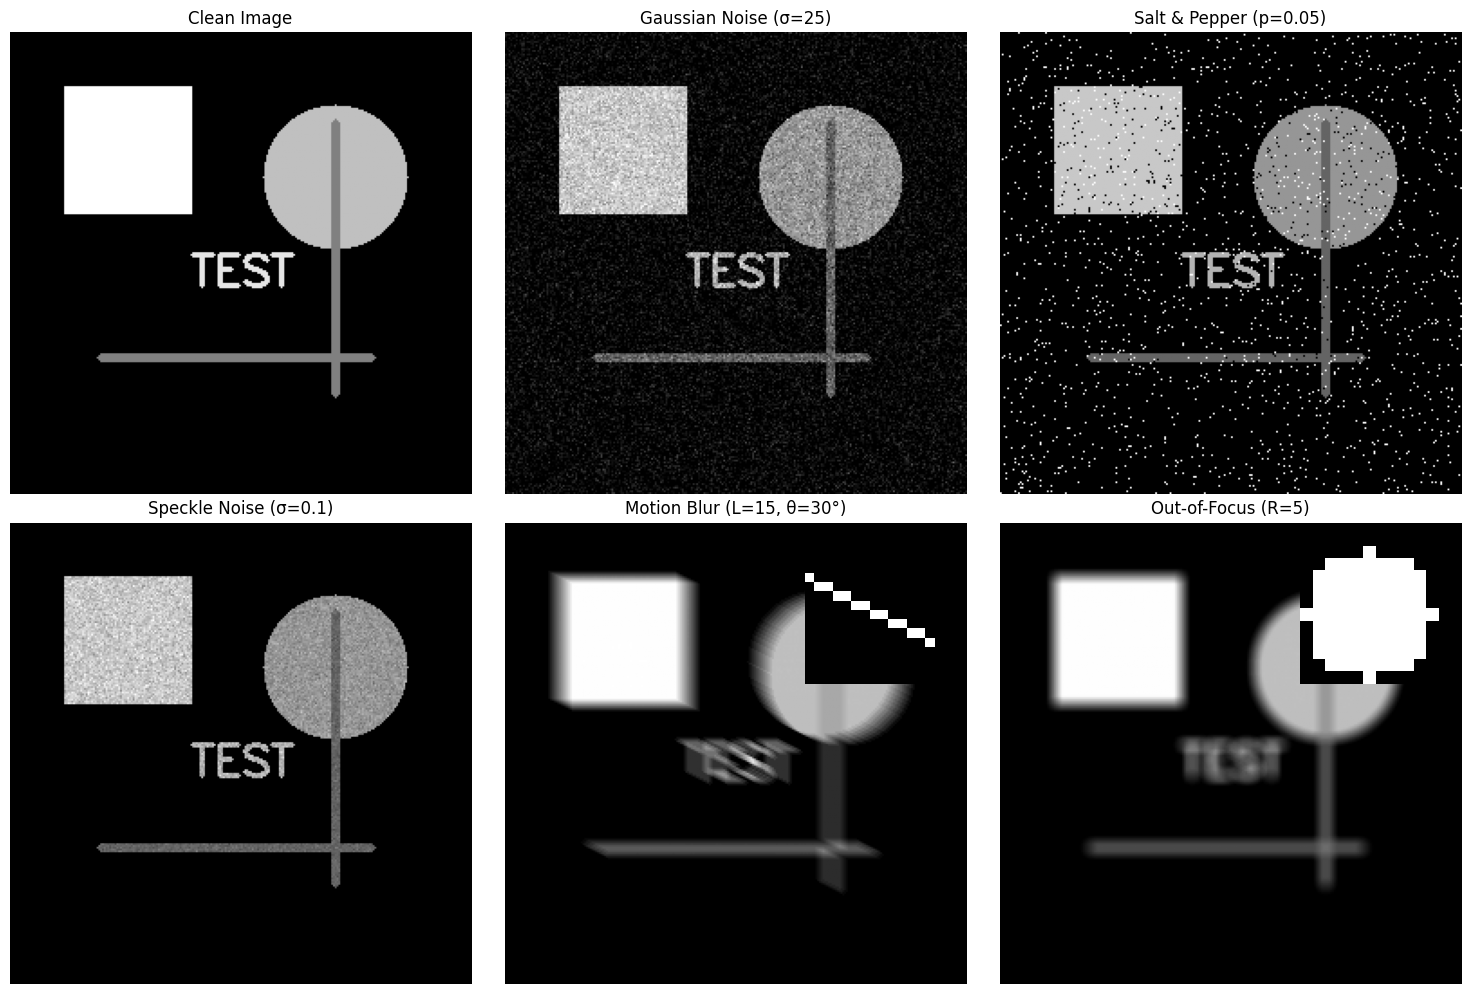


DEGRADATION METRICS COMPARISON
------------------------------------------------------------
Degradation Type          Mean       Std Dev    PSNR (dB)   
------------------------------------------------------------
Gaussian Noise (σ=25)     37.51      63.65      22.60       
Salt & Pepper (p=0.05)    34.33      72.63      16.48       
Speckle Noise (σ=0.1)     29.53      65.50      30.91       
Motion Blur (L=15, θ=30°) 29.43      59.65      21.88       
Out-of-Focus (R=5)        29.42      60.05      22.48       


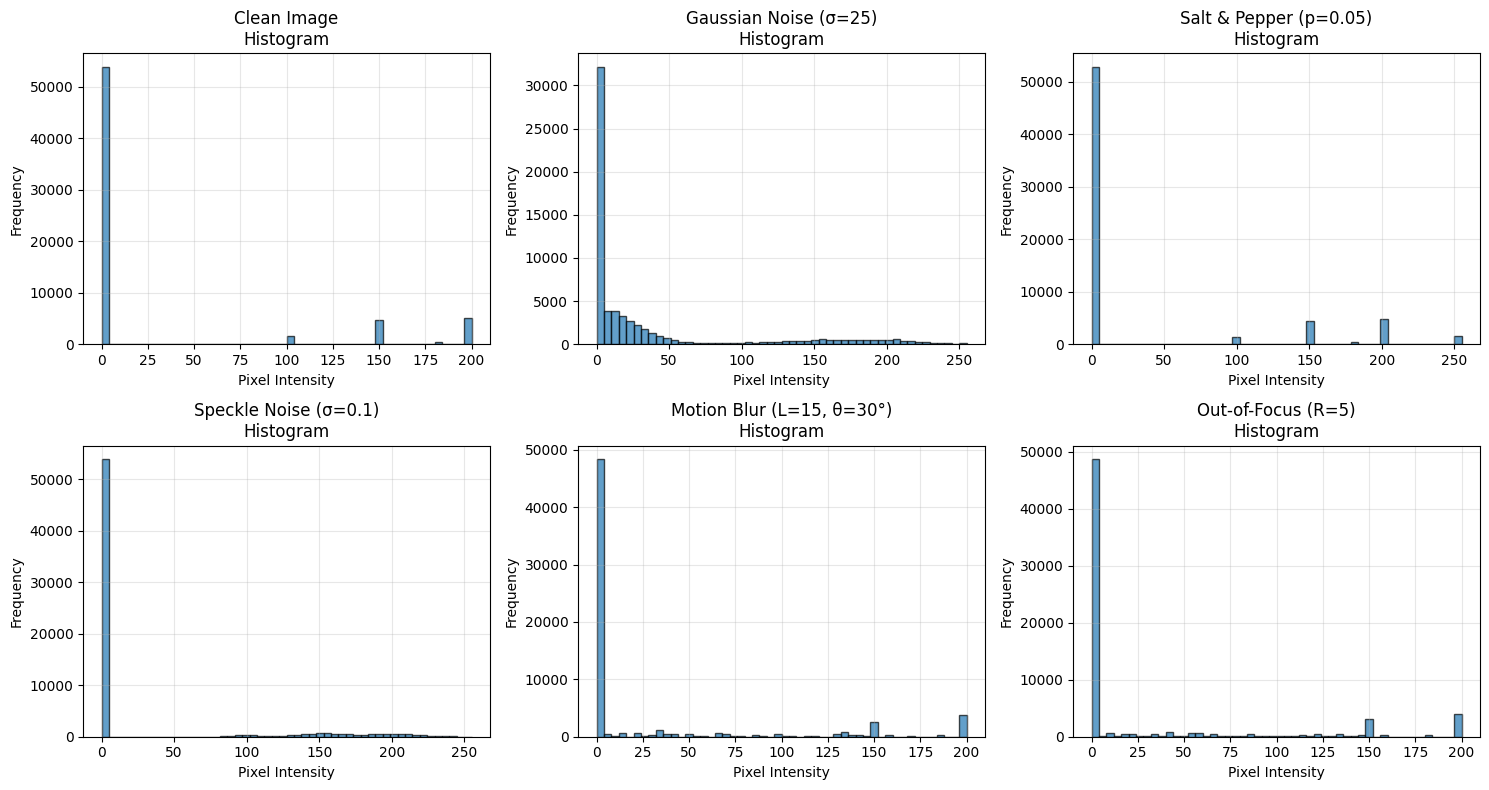

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft2, ifft2, fftshift, ifftshift

def praktikum_6_1():
    """
    Simulasi degradasi citra dengan berbagai jenis noise
    """
    print("PRAKTIKUM 6.1: SIMULASI DEGRADASI CITRA")
    print("=" * 50)

    # Load atau buat citra test
    def create_test_image():
        """Create synthetic test image with various features"""
        img = np.zeros((256, 256), dtype=np.uint8)

        # Add different patterns
        cv2.rectangle(img, (30, 30), (100, 100), 200, -1)  # Bright rectangle
        cv2.circle(img, (180, 80), 40, 150, -1)  # Medium circle
        cv2.line(img, (50, 180), (200, 180), 100, 3)  # Horizontal line
        cv2.line(img, (180, 50), (180, 200), 100, 3)  # Vertical line

        # Add text for detail
        cv2.putText(img, 'TEST', (100, 140), cv2.FONT_HERSHEY_SIMPLEX,
                   0.8, 180, 2)

        return img

    # Function untuk menambahkan berbagai jenis noise
    def add_gaussian_noise(image, mean=0, sigma=25):
        """Add Gaussian noise"""
        noise = np.random.normal(mean, sigma, image.shape)
        noisy = np.clip(image.astype(float) + noise, 0, 255)
        return noisy.astype(np.uint8)

    def add_salt_pepper_noise(image, prob=0.05):
        """Add salt and pepper noise"""
        noisy = image.copy()
        total_pixels = image.size

        # Salt noise (white)
        num_salt = int(total_pixels * prob / 2)
        salt_coords = [np.random.randint(0, i, num_salt) for i in image.shape]
        noisy[salt_coords[0], salt_coords[1]] = 255

        # Pepper noise (black)
        num_pepper = int(total_pixels * prob / 2)
        pepper_coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
        noisy[pepper_coords[0], pepper_coords[1]] = 0

        return noisy

    def add_speckle_noise(image, sigma=0.1):
        """Add multiplicative speckle noise"""
        noise = np.random.normal(1, sigma, image.shape)
        noisy = np.clip(image.astype(float) * noise, 0, 255)
        return noisy.astype(np.uint8)

    def add_motion_blur(image, length=15, angle=0):
        """Add motion blur degradation"""
        # Create motion blur kernel
        kernel = np.zeros((length, length))

        # Center of kernel
        center = length // 2

        # Draw line based on angle
        angle_rad = np.deg2rad(angle)
        x_start = int(center - (length/2) * np.cos(angle_rad))
        y_start = int(center - (length/2) * np.sin(angle_rad))
        x_end = int(center + (length/2) * np.cos(angle_rad))
        y_end = int(center + (length/2) * np.sin(angle_rad))

        cv2.line(kernel, (x_start, y_start), (x_end, y_end), 1, 1)

        # Normalize kernel
        kernel = kernel / np.sum(kernel)

        # Apply convolution
        blurred = cv2.filter2D(image.astype(float), -1, kernel)

        return np.clip(blurred, 0, 255).astype(np.uint8), kernel

    def add_out_of_focus_blur(image, radius=5):
        """Add out-of-focus blur"""
        # Create circular kernel
        kernel_size = 2 * radius + 1
        kernel = np.zeros((kernel_size, kernel_size))

        # Draw circle
        center = radius
        y, x = np.ogrid[-center:kernel_size-center, -center:kernel_size-center]
        mask = x**2 + y**2 <= radius**2
        kernel[mask] = 1

        # Normalize
        kernel = kernel / np.sum(kernel)

        # Apply blur
        blurred = cv2.filter2D(image.astype(float), -1, kernel)

        return np.clip(blurred, 0, 255).astype(np.uint8), kernel

    # Create clean image
    clean_img = create_test_image()

    # Apply different degradations
    degradations = {
        'Clean Image': (clean_img, None),
        'Gaussian Noise (σ=25)': (add_gaussian_noise(clean_img, 0, 25), None),
        'Salt & Pepper (p=0.05)': (add_salt_pepper_noise(clean_img, 0.05), None),
        'Speckle Noise (σ=0.1)': (add_speckle_noise(clean_img, 0.1), None),
        'Motion Blur (L=15, θ=30°)': add_motion_blur(clean_img, 15, 30),
        'Out-of-Focus (R=5)': add_out_of_focus_blur(clean_img, 5)
    }

    # Display results
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for idx, (title, degradation) in enumerate(degradations.items()):
        if isinstance(degradation, tuple) and len(degradation) == 2:
            degraded_img, kernel = degradation
        else:
            degraded_img = degradation
            kernel = None

        axes[idx].imshow(degraded_img, cmap='gray')
        axes[idx].set_title(title)
        axes[idx].axis('off')

        # Display kernel jika ada
        if kernel is not None and idx >= 4:  # Untuk motion blur dan out-of-focus
            # Create inset untuk kernel
            inset_ax = axes[idx].inset_axes([0.65, 0.65, 0.3, 0.3])
            inset_ax.imshow(kernel, cmap='gray')
            inset_ax.set_title('PSF')
            inset_ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Calculate and display metrics
    print("\nDEGRADATION METRICS COMPARISON")
    print("-" * 60)
    print(f"{'Degradation Type':<25} {'Mean':<10} {'Std Dev':<10} {'PSNR (dB)':<12}")
    print("-" * 60)

    for title, degradation in degradations.items():
        if title == 'Clean Image':
            continue

        if isinstance(degradation, tuple) and len(degradation) == 2:
            degraded_img, _ = degradation
        else:
            degraded_img = degradation

        # Calculate metrics
        mean_val = np.mean(degraded_img)
        std_val = np.std(degraded_img)

        # Calculate PSNR relative to clean image
        mse = np.mean((clean_img.astype(float) - degraded_img.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

        print(f"{title:<25} {mean_val:<10.2f} {std_val:<10.2f} {psnr:<12.2f}")

    # Histogram analysis
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()

    for idx, (title, degradation) in enumerate(degradations.items()):
        if isinstance(degradation, tuple) and len(degradation) == 2:
            degraded_img, _ = degradation
        else:
            degraded_img = degradation

        axes[idx].hist(degraded_img.ravel(), bins=50, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'{title}\nHistogram')
        axes[idx].set_xlabel('Pixel Intensity')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return clean_img, degradations

clean_img, degradations = praktikum_6_1()